In [1]:
import stim

from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp

%load_ext autoreload
%autoreload 2

In [4]:
code = "17_1_5"
max_col_ops = 100

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="X"
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print("Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.")

Loading QECC: 17_1_5
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100)...
Computing initial single faults...

Running verification stabilizers search for t=2 layers (top_n=50, first_layer=X)...

--- X Faults Verification (Non-FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 22.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 22.0
Injected 18 Z faults into Z-verification pool.

--- Z Faults Verification (FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 23.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 23.0

Synthesizing X fault verification circuits...

Synthesizing Z fault verification circuits...

--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 25
Num CX: 67
Total instructions: 79
Circuit output omitted to avoid terminal spam. You can export or print `final

Num CX: 67


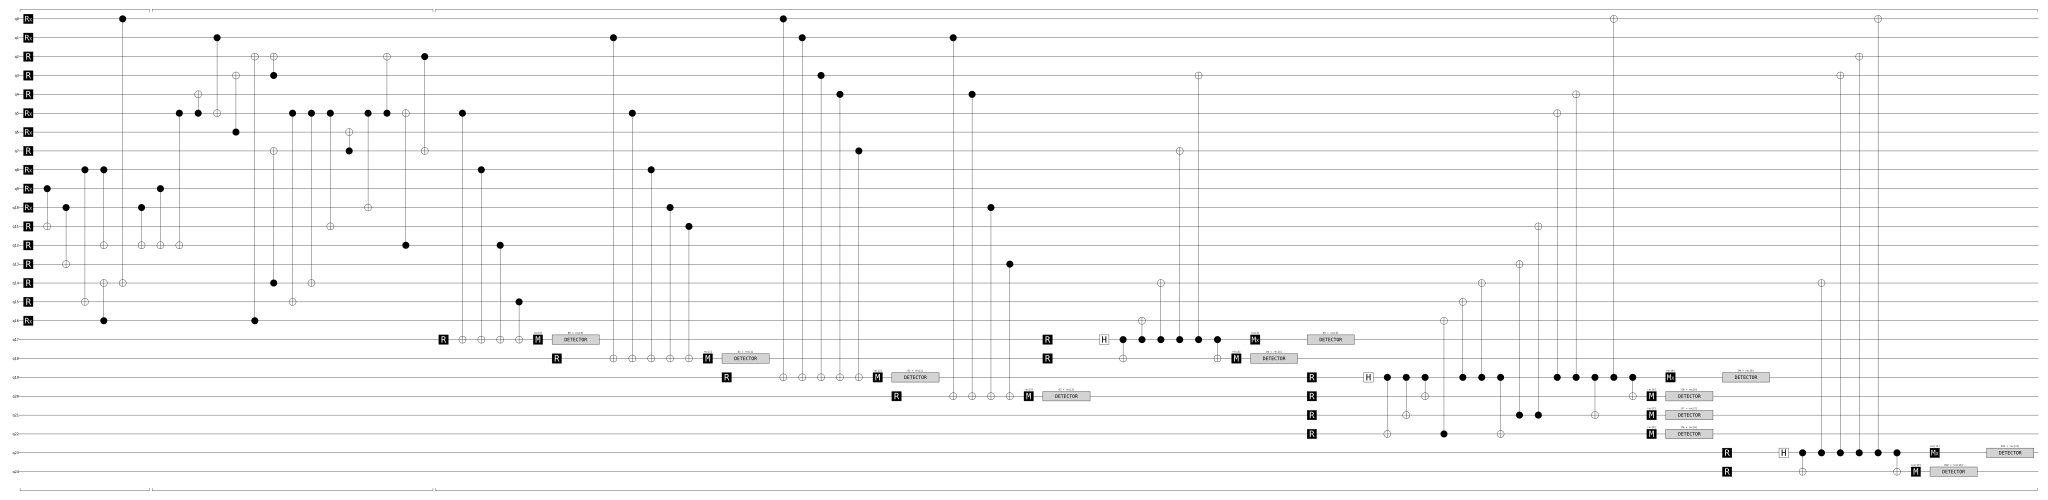

In [5]:
print(f"Num CX: {count_operations(final_circ)[0]}")

final_circ.diagram('timeline-svg')

In [6]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print((meas_samples @ L_z.T % 2).T)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[[0 0 0 0 0]]


In [7]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_z, L_primary=np.atleast_2d(L_z),
        H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
        d=d, t=d // 2,
        primary_basis="Z", conjugate_basis="X",
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis (d=5, t=2)...
    [PASS] UNSAT. The state preparation is strictly Fault-Tolerant.

  [Conjugate] Evaluating X-basis via Combinatorics (t=2)...
    [FAIL] Bad Conjugate Cascade Detected!
    Extracting deterministic failure circuit...
Verification Result: False


In [322]:
with open(f"{code}_failure.svg", "w", encoding="utf-8") as f:
    f.write(str(res_exhaustive.diagram('timeline-svg')))

In [202]:
if False:
    file = get_project_root().joinpath("good_circuits", f"{code}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

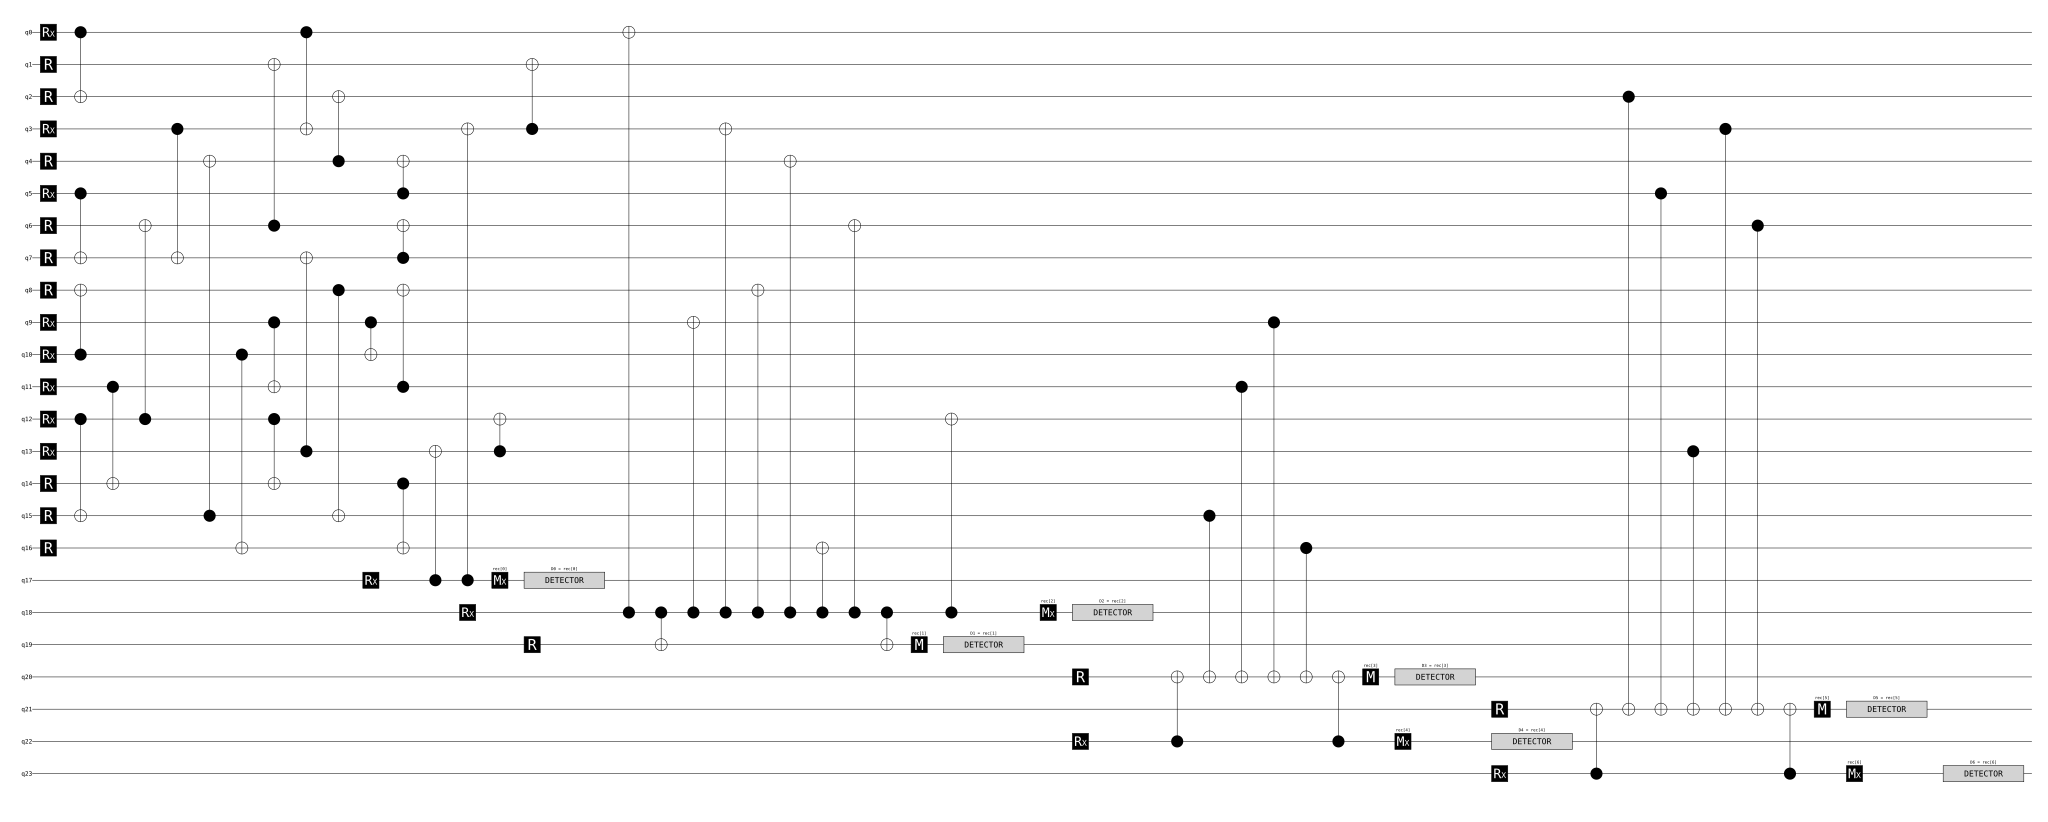

In [167]:
bens_circ = stim.Circuit("""
RX 0
R 1
R 2
RX 3
R 4
RX 5
R 6
R 7
R 8
RX 9
RX 10
RX 11
RX 12
RX 13
R 14
R 15
R 16
CX 12 15
CX 5 7
CX 10 8
CX 0 2
CX 11 14
CX 12 6
CX 3 7
CX 15 4
CX 10 16
CX 9 11
CX 12 14
CX 6 1
CX 13 7
CX 0 3
CX 8 15
CX 4 2
CX 9 10
RX 17
CX 11 8
CX 5 4
CX 14 16
CX 7 6
CX 17 13
CX 17 3
RX 18
CX 13 12
MX 17
DETECTOR rec[-1]
CX 3 1
R 19
CX 18 0
CX 18 19
CX 18 9
CX 18 3
CX 18 8
CX 18 4
CX 18 16
CX 18 6
CX 18 19
M 19
DETECTOR rec[-1]
CX 18 12
MX 18
DETECTOR rec[-1]
R 20
RX 22
CX 22 20
CX 15 20
CX 11 20
CX 9 20
CX 16 20
CX 22 20
M 20
DETECTOR rec[-1]
MX 22
DETECTOR rec[-1]
R 21
RX 23
CX 23 21
CX 2 21
CX 5 21
CX 13 21
CX 3 21
CX 6 21
CX 23 21
M 21
DETECTOR rec[-1]
MX 23
DETECTOR rec[-1]
""")
bens_circ.diagram("timeline-svg")

In [168]:
x_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1]
])

z_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
])

z_logs_17_1_5 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ z_stabs_17_1_5.T % 2)
print(meas_samples @ z_logs_17_1_5.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[0 0 0 0 0 0 0 0 0 0]


In [181]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(bens_circ, z_stabs_17_1_5, np.atleast_2d(z_logs_17_1_5), 5, 2, verbose=True)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

Starting Exact ILP Verification for Z-basis (d=5, t=2).
    [FAIL] Catastrophic cascade found!
    W(E_init)=2 faults bypassed flags to require only W(E_data)=2 to fail.
    Extracting unified failure circuit (Prep Faults + Data Faults)...
Verification Result: False


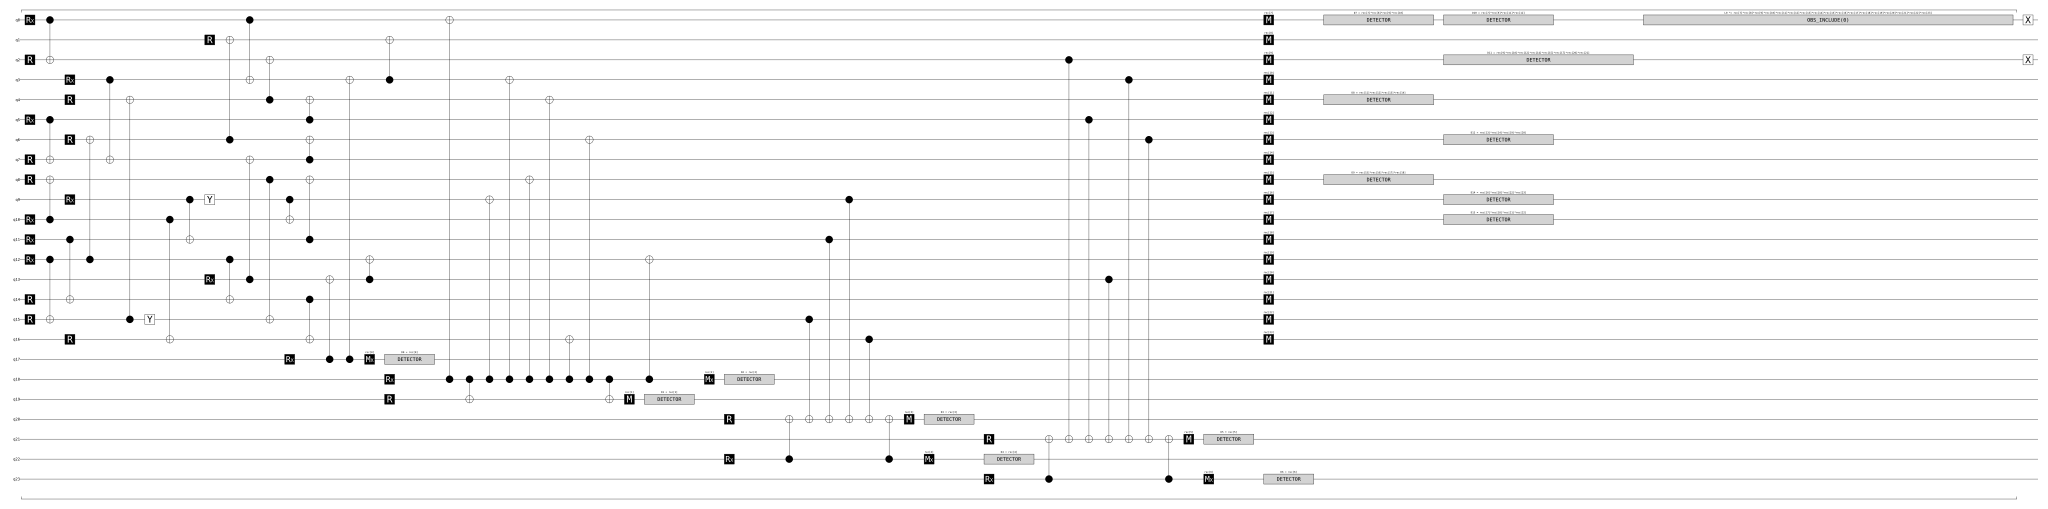

In [179]:
res_exhaustive.diagram('timeline-svg')

In [225]:
temp_circ = stim.Circuit('''
R 0
RX 1
R 2
RX 3 4
R 5
RX 6
R 7 8
RX 9
R 10 11
CX 1 7 6 11 1 8 6 5 9 8 4 5 9 10 4 0 3 0 3 10
TICK
CX 6 2 2 10 1 5 8 11 3 8 0 7 0 6 5 0
TICK
H 0 2 8 9
R 12 13
H 12
CX 12 13 12 9 12 8 12 2 12 0 12 13
M 13
DETECTOR rec[-1]
MX 12
H 0 2 8 9
DETECTOR rec[-1]
H 6 7 8 10
R 14 15
H 14
CX 14 15 14 10 14 8 14 7 14 6 14 15
M 15
DETECTOR rec[-1]
MX 14
H 6 7 8 10
DETECTOR rec[-1]
H 5 7 8 11
R 16 17
H 16
CX 16 17 16 11 16 8 16 7 16 5 16 17
M 17
DETECTOR rec[-1]
MX 16
H 5 7 8 11
DETECTOR rec[-1]
R 12 13
H 12
CX 12 13 12 3 12 2 12 1 12 0 12 13
M 13
DETECTOR rec[-1]
MX 12
DETECTOR rec[-1]
''')
count_operations(temp_circ)

(42, 8)

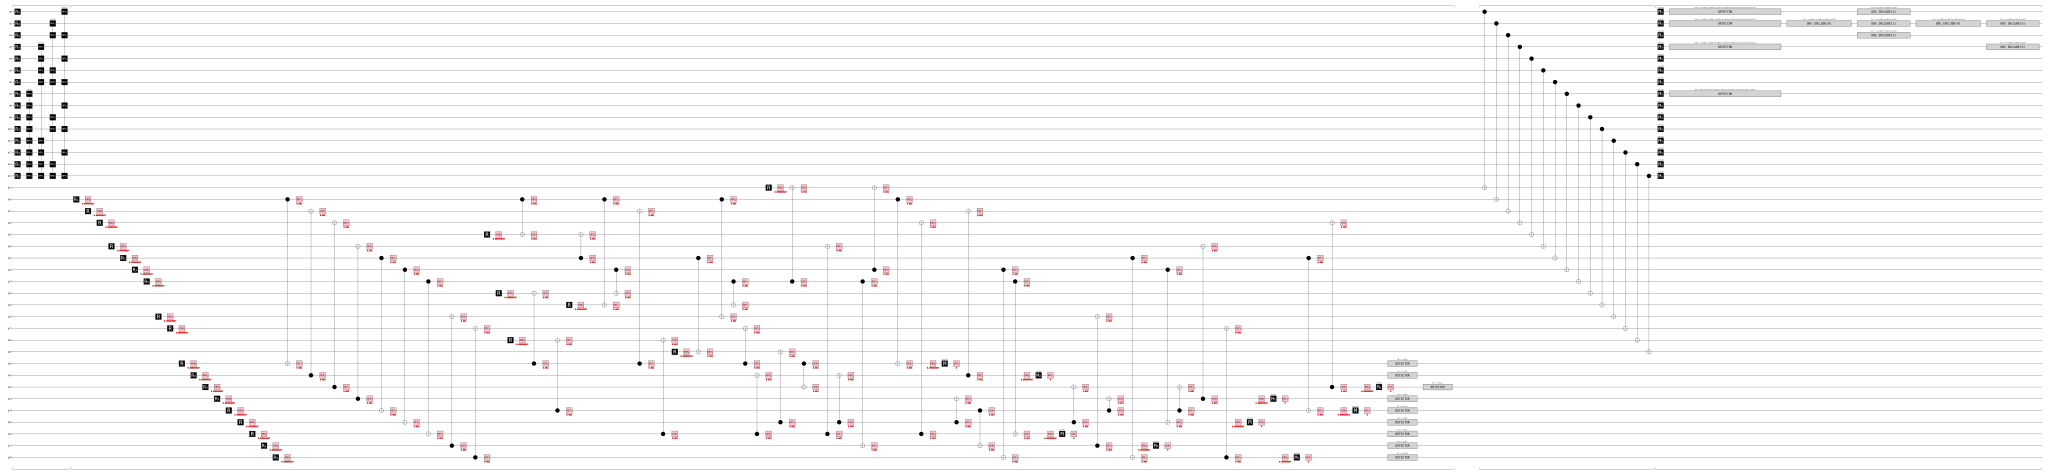

In [342]:
import stim

stim.Circuit('''
RX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
MPP Z7*Z8*Z9*Z10*Z11*Z12*Z13*Z14 Z3*Z4*Z5*Z6*Z11*Z12*Z13*Z14 Z1*Z2*Z5*Z6*Z9*Z10*Z13*Z14 Z0*Z2*Z4*Z6*Z8*Z10*Z12*Z14
TICK
RX 16
Z_ERROR(0.000666667) 16
R 17
X_ERROR(0.000666667) 17
R 18
X_ERROR(0.000666667) 18
R 20
X_ERROR(0.000666667) 20
RX 21
Z_ERROR(0.000666667) 21
RX 22
Z_ERROR(0.000666667) 22
RX 23
Z_ERROR(0.000666667) 23
R 26
X_ERROR(0.000666667) 26
R 27
X_ERROR(0.000666667) 27
R 30
X_ERROR(0.000666667) 30
RX 31
Z_ERROR(0.000666667) 31
RX 32
Z_ERROR(0.000666667) 32
RX 33
Z_ERROR(0.000666667) 33
R 34
X_ERROR(0.000666667) 34
R 35
X_ERROR(0.000666667) 35
R 36
X_ERROR(0.000666667) 36
RX 37
Z_ERROR(0.000666667) 37
RX 38
Z_ERROR(0.000666667) 38
CX 16 30
DEPOLARIZE1(0.001) 16 30
CX 31 17
DEPOLARIZE1(0.001) 31 17
CX 32 18
DEPOLARIZE1(0.001) 32 18
CX 33 20
DEPOLARIZE1(0.001) 33 20
CX 21 34
DEPOLARIZE1(0.001) 21 34
CX 22 35
DEPOLARIZE1(0.001) 22 35
CX 23 36
DEPOLARIZE1(0.001) 23 36
CX 37 26
DEPOLARIZE1(0.001) 37 26
CX 38 27
DEPOLARIZE1(0.001) 38 27
R 19
X_ERROR(0.000666667) 19
R 24
X_ERROR(0.000666667) 24
R 28
X_ERROR(0.000666667) 28
CX 16 19
DEPOLARIZE1(0.001) 16 19
CX 30 24
DEPOLARIZE1(0.001) 30 24
CX 34 28
DEPOLARIZE1(0.001) 34 28
R 25
X_ERROR(0.000666667) 25
CX 21 19
DEPOLARIZE1(0.001) 21 19
CX 16 25
DEPOLARIZE1(0.001) 16 25
CX 22 24
DEPOLARIZE1(0.001) 22 24
CX 30 17
DEPOLARIZE1(0.001) 30 17
CX 36 28
DEPOLARIZE1(0.001) 36 28
R 29
X_ERROR(0.000666667) 29
CX 21 29
DEPOLARIZE1(0.001) 21 29
CX 16 26
DEPOLARIZE1(0.001) 16 26
CX 23 25
DEPOLARIZE1(0.001) 23 25
CX 30 27
DEPOLARIZE1(0.001) 30 27
CX 36 31
DEPOLARIZE1(0.001) 36 31
R 15
X_ERROR(0.000666667) 15
CX 35 29
DEPOLARIZE1(0.001) 35 29
CX 23 15
DEPOLARIZE1(0.001) 23 15
CX 30 32
DEPOLARIZE1(0.001) 30 32
CX 36 20
DEPOLARIZE1(0.001) 36 20
CX 35 31
DEPOLARIZE1(0.001) 35 31
CX 23 37
DEPOLARIZE1(0.001) 23 37
CX 22 15
DEPOLARIZE1(0.001) 22 15
CX 16 30
DEPOLARIZE1(0.001) 16 30
CX 36 18
DEPOLARIZE1(0.001) 36 18
X_ERROR(0.000666667) 30
M 30
DEPOLARIZE1(0) 30
CX 35 33
DEPOLARIZE1(0.001) 35 33
CX 31 17
DEPOLARIZE1(0.001) 31 17
CX 34 37
DEPOLARIZE1(0.001) 34 37
CX 22 38
DEPOLARIZE1(0.001) 22 38
CX 23 36
DEPOLARIZE1(0.001) 23 36
Z_ERROR(0.000666667) 31
MX 31
DEPOLARIZE1(0) 31
X_ERROR(0.000666667) 36
M 36
DEPOLARIZE1(0) 36
CX 35 32
DEPOLARIZE1(0.001) 35 32
CX 37 26
DEPOLARIZE1(0.001) 37 26
CX 34 33
DEPOLARIZE1(0.001) 34 33
CX 21 38
DEPOLARIZE1(0.001) 21 38
Z_ERROR(0.000666667) 37
MX 37
DEPOLARIZE1(0) 37
CX 22 35
DEPOLARIZE1(0.001) 22 35
CX 34 32
DEPOLARIZE1(0.001) 34 32
CX 33 20
DEPOLARIZE1(0.001) 33 20
CX 38 27
DEPOLARIZE1(0.001) 38 27
X_ERROR(0.000666667) 35
M 35
DEPOLARIZE1(0) 35
Z_ERROR(0.000666667) 33
MX 33
DEPOLARIZE1(0) 33
Z_ERROR(0.000666667) 38
MX 38
DEPOLARIZE1(0) 38
CX 21 34
DEPOLARIZE1(0.001) 21 34
CX 32 18
DEPOLARIZE1(0.001) 32 18
X_ERROR(0.000666667) 34
M 34
DEPOLARIZE1(0) 34
Z_ERROR(0.000666667) 32
MX 32
DEPOLARIZE1(0) 32
DETECTOR rec[-9]
DETECTOR rec[-8]
DETECTOR rec[-7]
DETECTOR rec[-6]
DETECTOR rec[-5]
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]
TICK
TICK
TICK
CX 0 15 1 16 2 17 3 18 4 19 5 20 6 21 7 22 8 23 9 24 10 25 11 26 12 27 13 28 14 29
TICK
MX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
DETECTOR rec[-8] rec[-7] rec[-6] rec[-5] rec[-4] rec[-3] rec[-2] rec[-1]
DETECTOR rec[-12] rec[-11] rec[-10] rec[-9] rec[-4] rec[-3] rec[-2] rec[-1]
DETECTOR rec[-14] rec[-13] rec[-10] rec[-9] rec[-6] rec[-5] rec[-2] rec[-1]
DETECTOR rec[-15] rec[-13] rec[-11] rec[-9] rec[-7] rec[-5] rec[-3] rec[-1]
OBSERVABLE_INCLUDE(0) rec[-14] rec[-13] rec[-12] rec[-11]
OBSERVABLE_INCLUDE(1) rec[-14] rec[-12] rec[-10]
OBSERVABLE_INCLUDE(2) rec[-13] rec[-12] rec[-9]
OBSERVABLE_INCLUDE(3) rec[-15] rec[-14] rec[-13]
OBSERVABLE_INCLUDE(4) rec[-14] rec[-13] rec[-8] rec[-7]
OBSERVABLE_INCLUDE(5) rec[-14] rec[-8] rec[-6]
OBSERVABLE_INCLUDE(6) rec[-12] rec[-8] rec[-4]
''').diagram('timeline-svg')
# ''').compile_detector_sampler().sample(10, prepend_observables=True).astype(int)